In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('../data/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.shape

(4269, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [5]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [6]:
df.drop('loan_id',axis=1,inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns=df.columns.str.strip()

In [9]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [10]:
print(df.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='str')


In [11]:
df['loan_status'].unique()

<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str

In [12]:
df['loan_status']=df['loan_status'].map({' Approved':1,' Rejected':0})

In [13]:
df['loan_status']

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [14]:
df['loan_status'].value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [15]:
print(df['education'].unique())
df['education']=df['education'].str.strip().map({'Graduate':1,'Not Graduate':0})

<StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str


In [16]:
df['self_employed'].unique()
df['self_employed']=df['self_employed'].str.strip().map({'Yes':1,'No':0})

In [17]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
# from imblearn.over_sampling import SMOTE

In [20]:
# smote=SMOTE(random_state=42)
# x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)
# print(pd.Series(y_train_smote).value_counts())

In [21]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [22]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logisticpipeline=Pipeline([
  ('scalar',StandardScaler()),
  ('logistic',LogisticRegression(random_state=42))
])

In [23]:
results=[]

In [24]:
from sklearn.metrics import f1_score,precision_score,recall_score,classification_report
def evaluate(model,model_name):
  model.fit(x_train,y_train)  
  y_pred=model.predict(x_test)
  results.append({
    'model_name': model_name,
    'f1_score': f1_score(y_test, y_pred),
    'precision_score': precision_score(y_test, y_pred),
    'recall_score': recall_score(y_test, y_pred)
  })
  print(f"{model_name}",classification_report(y_test, y_pred))

In [25]:
evaluate(logisticpipeline,'Logistic Regression')

Logistic Regression               precision    recall  f1-score   support

           0       0.88      0.86      0.87       318
           1       0.92      0.93      0.92       536

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

In [27]:
models={
  'Decision Tree': DecisionTreeClassifier(random_state=42),
  'Random Forest': RandomForestClassifier(random_state=42),
  'XGBoost': XGBClassifier(random_state=42),
  'AdaBoost': AdaBoostClassifier(random_state=42)
}

for model_name,model in models.items():
  tree_pipeline=Pipeline([
    ('model',model)
  ])
  evaluate(tree_pipeline,model_name)

Decision Tree               precision    recall  f1-score   support

           0       0.97      0.97      0.97       318
           1       0.98      0.98      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Random Forest               precision    recall  f1-score   support

           0       0.98      0.97      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

XGBoost               precision    recall  f1-score   support

           0       0.98      0.97      0.98       318
           1       0.98      0.99      0.99       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98     

In [28]:
result_df=pd.DataFrame(results)
result_df

,model_name,f1_score,precision_score,recall_score
0,Logistic Regression,0.924791,0.920518,0.929104
1,Decision Tree,0.982293,0.981378,0.983209
2,Random Forest,0.984186,0.981447,0.986940
3,XGBoost,0.986047,0.983302,0.988806
4,AdaBoost,0.975746,0.975746,0.975746


In [29]:
xgboost=XGBClassifier(random_state=42)
xgboost.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [30]:
import joblib 
joblib.dump(xgboost,'xgboost_model.pkl')

['xgboost_model.pkl']

In [31]:
print(df.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='str')


In [32]:
model=joblib.load('xgboost_model.pkl')

In [33]:
import shap

d:\projects\LoanApprovalLLM\loanapprenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
explainer=shap.TreeExplainer(model)
shap_values=explainer.shap_values(x_test)

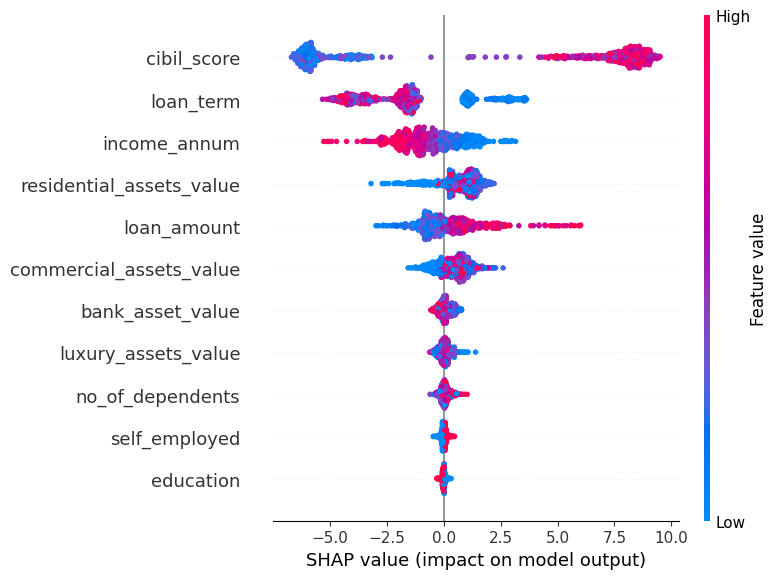

In [35]:
shap.summary_plot(shap_values,x_test)

In [36]:
import pandas as pd

# education: Graduate=1, Not Graduate=0
# self_employed: Yes=1, No=0
sample_test = pd.DataFrame([
    {
        "no_of_dependents": 2,
        "education": 1,
        "self_employed": 0,
        "income_annum": 850000,
        "loan_amount": 2200000,
        "loan_term": 12,
        "cibil_score": 780,
        "residential_assets_value": 1800000,
        "commercial_assets_value": 900000,
        "luxury_assets_value": 700000,
        "bank_asset_value": 500000
    }
])

In [37]:
def get_shap_explanation(input_data):
  shap_vals=explainer.shap_values(input_data)
  explanation = dict(zip(input_data.columns, shap_vals[0]))
    
    # sort by absolute impact
  explanation = dict(sorted(explanation.items(), 
                     key=lambda x: abs(x[1]), reverse=True))
  return explanation


In [38]:
print(get_shap_explanation(sample_test))

{'cibil_score': np.float32(7.7476025), 'loan_term': np.float32(-1.37962), 'residential_assets_value': np.float32(0.96711856), 'income_annum': np.float32(0.9216596), 'no_of_dependents': np.float32(-0.34522125), 'commercial_assets_value': np.float32(0.3054629), 'luxury_assets_value': np.float32(-0.16162194), 'bank_asset_value': np.float32(-0.13250977), 'self_employed': np.float32(-0.09531011), 'education': np.float32(-0.076932706), 'loan_amount': np.float32(-0.004987262)}
